CNN
---
This project applies a Convolutional Neural Network (CNN) on the **"Women's E-Commerce Clothing Reviews"** dataset to classify reviews as positive or negative based on text. It uses a **vocabulary size of 10,000**, **embedding dimension of 128**, **sequence length of 100**, and trains the model for **15 epochs** with **batch size 128** and **EarlyStopping** based on validation loss.


🗃️ Dataset Summary
🔢 Total Reviews: 22641
✅ Positive Reviews: 17448
❌ Negative Reviews: 5193



/tmp/ipython-input-11-2023169351.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Sentiment', palette='Set2')
/tmp/ipython-input-11-2023169351.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Rating', palette='rocket')


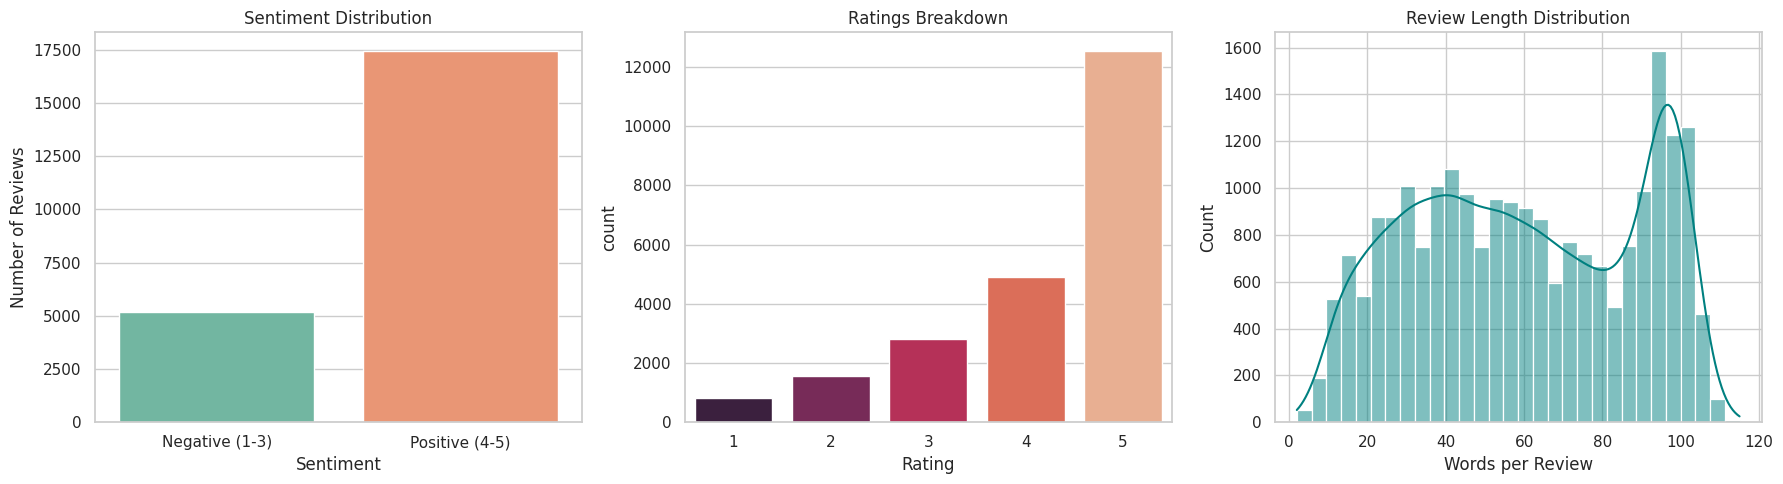


📚 Training CNN model (15 epochs)...

Epoch 1/15


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


114/114 ━━━━━━━━━━━━━━━━━━━━ 25s 193ms/step - accuracy: 0.7578 - loss: 0.5214 - val_accuracy: 0.8322 - val_loss: 0.3552
Epoch 2/15
114/114 ━━━━━━━━━━━━━━━━━━━━ 42s 201ms/step - accuracy: 0.8672 - loss: 0.2965 - val_accuracy: 0.8648 - val_loss: 0.3076
Epoch 3/15
114/114 ━━━━━━━━━━━━━━━━━━━━ 41s 201ms/step - accuracy: 0.9256 - loss: 0.1910 - val_accuracy: 0.8661 - val_loss: 0.3399
Epoch 4/15
114/114 ━━━━━━━━━━━━━━━━━━━━ 40s 190ms/step - accuracy: 0.9555 - loss: 0.1220 - val_accuracy: 0.8628 - val_loss: 0.3645
Epoch 5/15
114/114 ━━━━━━━━━━━━━━━━━━━━ 42s 201ms/step - accuracy: 0.9751 - loss: 0.0793 - val_accuracy: 0.8567 - val_loss: 0.5485
Epoch 6/15
114/114 ━━━━━━━━━━━━━━━━━━━━ 41s 201ms/step - accuracy: 0.9899 - loss: 0.0381 - val_accuracy: 0.8590 - val_loss: 0.6745
Epoch 7/15
114/114 ━━━━━━━━━━━━━━━━━━━━ 42s 212ms/step - accuracy: 0.9949 - loss: 0.0195 - val_accuracy: 0.8548 - val_loss: 0.8527
Epoch 8/15
114/114 ━━━━━━━━━━━━━━━━━━━━ 40s 201ms/step - accuracy: 0.9980 - loss: 0.0097 - val

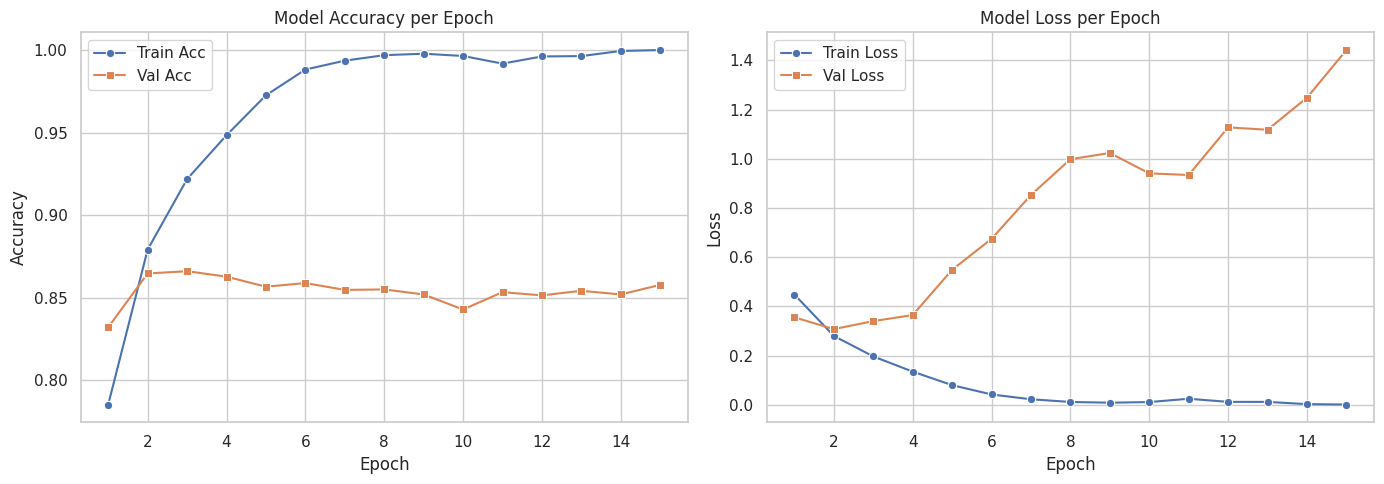


✅ Final Test Accuracy: 0.8607
❌ Final Test Loss: 1.3898
142/142 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step

📝 Classification Report:
              precision    recall  f1-score   support

    Negative       0.75      0.59      0.66      1045
    Positive       0.88      0.94      0.91      3484

    accuracy                           0.86      4529
   macro avg       0.82      0.76      0.79      4529
weighted avg       0.85      0.86      0.85      4529



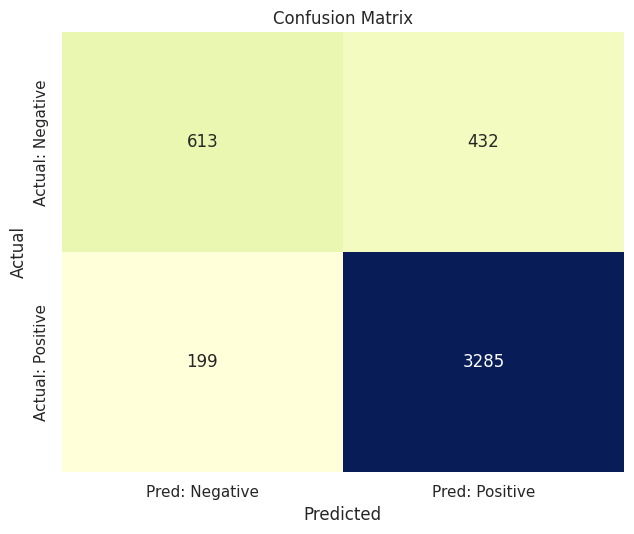

In [11]:

import kagglehub
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import rcParams

# Set Seaborn and Matplotlib style
sns.set(style="whitegrid")
rcParams['figure.figsize'] = (12, 6)
plt.rcParams.update({'font.size': 12})

# 🎯 Load dataset
path = kagglehub.dataset_download("nicapotato/womens-ecommerce-clothing-reviews")
df = pd.read_csv(f"{path}/Womens Clothing E-Commerce Reviews.csv")

# ✂️ Preprocess: keep text + rating, drop missing
df = df[['Review Text', 'Rating']].dropna()
df['Sentiment'] = (df['Rating'] >= 4).astype(int)

# 📊 Basic info
print("🗃️ Dataset Summary")
print(f"🔢 Total Reviews: {len(df)}")
print(f"✅ Positive Reviews: {df['Sentiment'].sum()}")
print(f"❌ Negative Reviews: {len(df) - df['Sentiment'].sum()}\n")

# ➕ Review length
df['Review Length'] = df['Review Text'].apply(lambda x: len(x.split()))

# 📈 Visualizations
plt.figure(figsize=(18, 5))

# 1️⃣ Sentiment Distribution
plt.subplot(1, 3, 1)
sns.countplot(data=df, x='Sentiment', palette='Set2')
plt.xticks([0, 1], ['Negative (1-3)', 'Positive (4-5)'])
plt.title('Sentiment Distribution')
plt.ylabel('Number of Reviews')

# 2️⃣ Rating Distribution
plt.subplot(1, 3, 2)
sns.countplot(data=df, x='Rating', palette='rocket')
plt.title('Ratings Breakdown')

# 3️⃣ Review Length
plt.subplot(1, 3, 3)
sns.histplot(df['Review Length'], bins=30, kde=True, color='teal')
plt.title('Review Length Distribution')
plt.xlabel('Words per Review')

plt.tight_layout()
plt.show()

# 🔡 Text Tokenization
tokenizer = Tokenizer(num_words=10000, oov_token="<OOV>")
tokenizer.fit_on_texts(df['Review Text'])
sequences = tokenizer.texts_to_sequences(df['Review Text'])
padded_sequences = pad_sequences(sequences, maxlen=100)

# 🧪 Train/Test split
X_train, X_test, y_train, y_test = train_test_split(
    padded_sequences, df['Sentiment'], test_size=0.2, random_state=42
)

# 🧠 CNN Model
cnn_model = keras.Sequential([
    layers.Embedding(input_dim=10000, output_dim=128, input_length=100),
    layers.Conv1D(128, 5, activation='relu'),
    layers.MaxPooling1D(pool_size=2),
    layers.Conv1D(64, 5, activation='relu'),
    layers.MaxPooling1D(pool_size=2),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(1, activation='sigmoid')
])

cnn_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# 🚀 Train model
print("\n📚 Training CNN model (15 epochs)...\n")
cnn_history = cnn_model.fit(
    X_train, y_train,
    epochs=15,
    batch_size=128,
    validation_split=0.2,
    verbose=1
)

# 📊 Plot Training History
plt.figure(figsize=(14, 5))

# Accuracy
plt.subplot(1, 2, 1)
sns.lineplot(x=range(1, 16), y=cnn_history.history['accuracy'], label='Train Acc', marker='o')
sns.lineplot(x=range(1, 16), y=cnn_history.history['val_accuracy'], label='Val Acc', marker='s')
plt.title("Model Accuracy per Epoch")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.grid(True)

# Loss
plt.subplot(1, 2, 2)
sns.lineplot(x=range(1, 16), y=cnn_history.history['loss'], label='Train Loss', marker='o')
sns.lineplot(x=range(1, 16), y=cnn_history.history['val_loss'], label='Val Loss', marker='s')
plt.title("Model Loss per Epoch")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)

plt.tight_layout()
plt.show()

# 📉 Evaluate
cnn_test_loss, cnn_test_acc = cnn_model.evaluate(X_test, y_test, verbose=0)
print(f"\n✅ Final Test Accuracy: {cnn_test_acc:.4f}")
print(f"❌ Final Test Loss: {cnn_test_loss:.4f}")

# 🔍 Predictions
cnn_y_pred = (cnn_model.predict(X_test) > 0.5).astype(int)

# 📄 Classification Report
print("\n📝 Classification Report:")
print(classification_report(y_test, cnn_y_pred, target_names=["Negative", "Positive"]))

# 🔳 Confusion Matrix (with %)
cm = confusion_matrix(y_test, cnn_y_pred)
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]  # normalize rows

plt.figure(figsize=(6.5, 5.5))
sns.heatmap(cm, annot=True, fmt='d', cmap='YlGnBu', cbar=False,
            xticklabels=['Pred: Negative', 'Pred: Positive'],
            yticklabels=['Actual: Negative', 'Actual: Positive'])
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()


LSTM


📚 Training LSTM model...
Epoch 1/15


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


114/114 ━━━━━━━━━━━━━━━━━━━━ 73s 562ms/step - accuracy: 0.7821 - loss: 0.5083 - val_accuracy: 0.8625 - val_loss: 0.3263
Epoch 2/15
114/114 ━━━━━━━━━━━━━━━━━━━━ 61s 538ms/step - accuracy: 0.8937 - loss: 0.2565 - val_accuracy: 0.8722 - val_loss: 0.3086
Epoch 3/15
114/114 ━━━━━━━━━━━━━━━━━━━━ 82s 543ms/step - accuracy: 0.9223 - loss: 0.1972 - val_accuracy: 0.8725 - val_loss: 0.3207
Epoch 4/15
114/114 ━━━━━━━━━━━━━━━━━━━━ 87s 592ms/step - accuracy: 0.9434 - loss: 0.1494 - val_accuracy: 0.8667 - val_loss: 0.3684
Epoch 5/15
114/114 ━━━━━━━━━━━━━━━━━━━━ 77s 547ms/step - accuracy: 0.9522 - loss: 0.1278 - val_accuracy: 0.8576 - val_loss: 0.4108


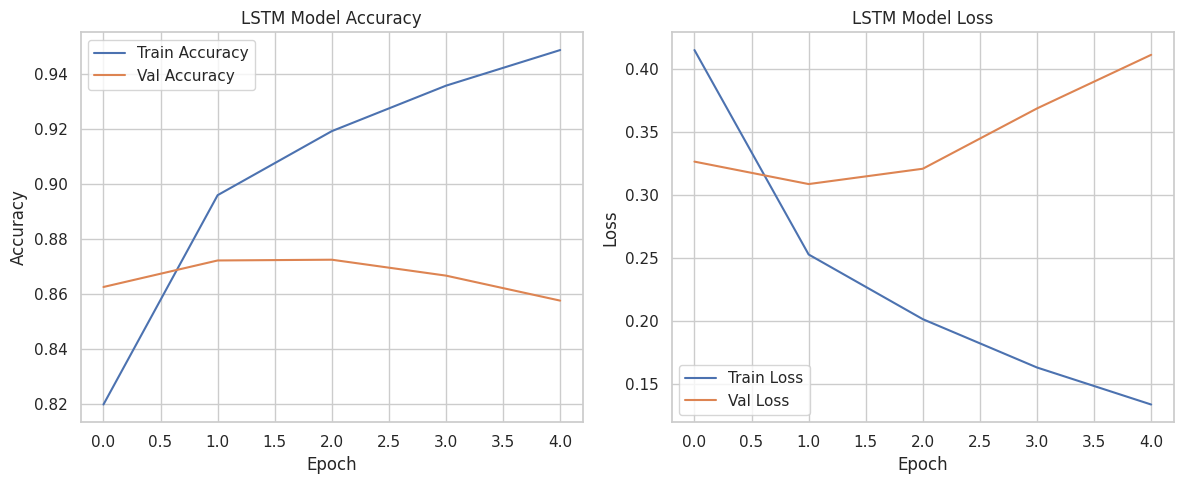


✅ LSTM Test Accuracy: 0.8788
❌ LSTM Test Loss: 0.2799
142/142 ━━━━━━━━━━━━━━━━━━━━ 9s 64ms/step

📄 Classification Report:
              precision    recall  f1-score   support

           0       0.75      0.70      0.73      1045
           1       0.91      0.93      0.92      3484

    accuracy                           0.88      4529
   macro avg       0.83      0.82      0.83      4529
weighted avg       0.88      0.88      0.88      4529



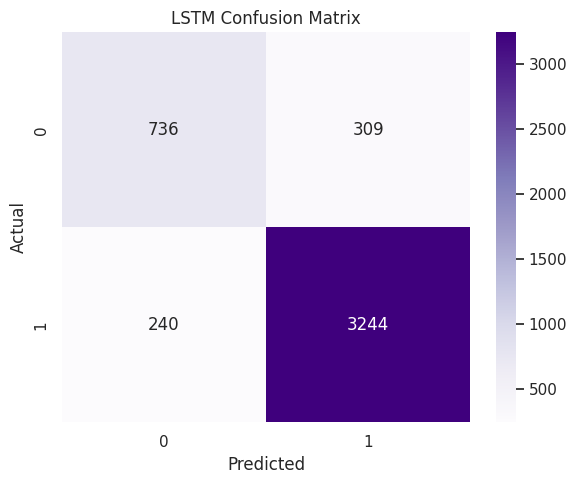

In [9]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
import matplotlib.pyplot as plt
import seaborn as sns

# 📥 Load dataset manually (update path if needed)
# 🎯 Load dataset
path = kagglehub.dataset_download("nicapotato/womens-ecommerce-clothing-reviews")
df = pd.read_csv(f"{path}/Womens Clothing E-Commerce Reviews.csv")

# 🧹 Clean and prepare
df = df[['Review Text', 'Rating']].dropna()
df['Sentiment'] = (df['Rating'] >= 4).astype(int)

# 🔠 Tokenization
tokenizer = Tokenizer(num_words=10000, oov_token="<OOV>")
tokenizer.fit_on_texts(df['Review Text'])
sequences = tokenizer.texts_to_sequences(df['Review Text'])
padded_sequences = pad_sequences(sequences, maxlen=100)

# 🔀 Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    padded_sequences, df['Sentiment'], test_size=0.2, random_state=42
)

# 🧠 LSTM Model
lstm_model = keras.Sequential([
    layers.Embedding(input_dim=10000, output_dim=128, input_length=100),
    layers.LSTM(128, return_sequences=True),
    layers.Dropout(0.5),
    layers.LSTM(64),
    layers.Dense(64, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

lstm_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# ⏱ EarlyStopping
early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

# 🚀 Train model
print("\n📚 Training LSTM model...")
lstm_history = lstm_model.fit(
    X_train, y_train,
    epochs=15,
    batch_size=128,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

# 📈 Plot training history
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(lstm_history.history['accuracy'], label='Train Accuracy')
plt.plot(lstm_history.history['val_accuracy'], label='Val Accuracy')
plt.title('LSTM Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(lstm_history.history['loss'], label='Train Loss')
plt.plot(lstm_history.history['val_loss'], label='Val Loss')
plt.title('LSTM Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

# 🔎 Evaluate on test set
lstm_test_loss, lstm_test_acc = lstm_model.evaluate(X_test, y_test, verbose=0)
print(f"\n✅ LSTM Test Accuracy: {lstm_test_acc:.4f}")
print(f"❌ LSTM Test Loss: {lstm_test_loss:.4f}")

# 🧾 Predictions
lstm_y_pred = (lstm_model.predict(X_test) > 0.5).astype(int)

# 📝 Classification Report
print("\n📄 Classification Report:")
print(classification_report(y_test, lstm_y_pred))

# 🔷 Confusion Matrix
cm = confusion_matrix(y_test, lstm_y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples')
plt.title('LSTM Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()
